In [15]:
import math
import numpy as np
import random
from matplotlib import pyplot as plt
from pedestrian import *
from scipy.signal import welch, detrend, butter, filtfilt
from solver import* #Phi_matrix ,accdyn_super,MatrixAssemblesymetric,calculate_frf_and_accelerance,g_pj
from matrix import bridge


#step 1 setup beam and pedestrians

#beam

length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 2

#ped
numped = 1
pedmass = 80     #kg
peddamp = .3    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 2 #Hz

#ped
kped1=(2*np.pi*pedBodyF)**2*pedmass
cped1 = (2*np.pi*pedBodyF)*2*peddamp*pedmass

mped = np.array([pedmass])
cped = np.array([cped1])
kped = np.array([kped1])


modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12

#set time info
hht=0.01

#initial possition vector.......formultiple ped all these would become matrices

#xrb=np.zeros(1,numped)
xrb=[0]

Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers =numbers  )                   #modes


N_bridge = 2




# probabilitstic parameters
mean_pace = 2 #Hz  2005 pachi
pace_COV = 0.1

mean_mass= 70 #kg
mass_COV= 0.17 #from butz 2008

mean_velocity = 1.3
std_velocity = 0.12 #pachi 2005

mean_alpha = np.array([0.41 * (mean_pace - 0.95),
                0.069 + 0.0056 * mean_pace,
                .033 + 0.0064 * mean_pace,
                0.013 + 0.0065 *mean_pace])

alpha_COV= np.array([0.17,0.4,0.4,0.4])


alpha_std = mean_alpha*alpha_COV

# Generate a random variable from a normal distribution with considered mean and std_dev from literiture

randomPace = random.gauss(mean_pace, pace_COV*mean_pace)
randomMass = random.gauss(mean_mass, mass_COV*mean_mass)
randomAlpha = [random.gauss(mean_alpha[i], alpha_std[i]) for i in range(len(alpha_COV))]
#randomPhase = [random.uniform(0, 2 * math.pi) for i in range(len(mean_alpha)+1)]
randomVelocity = random.gauss(mean_velocity,std_velocity)
randomPhase = np.zeros(5)


print(randomPace)
print(randomMass)
print(randomAlpha)
print(randomPhase)
print(randomVelocity)

t = np.array(np.arange(0, (length + 1) / randomVelocity, hht))

Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
        iSync=0)
'''
Human = Pedestrian(
         mass = randomMass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = randomPace ,    #Hz
         phase = randomPhase,
         location = pedInlocation,
         velocity = randomVelocity,
         
         iSync=0)'''

#ped = RandPedestrian(randomMass, randomPace, randomPhase, randomAlpha)
n=1
numped=1
#j=np.size(t)
xr=[0]
#force_at_time_t = np.zeros(np.size(t))


#modal force
F=np.zeros((N_bridge,np.size(t)))
for i in range (np.size(t)):
     
    force_at_time_t = calcDynamicPedForce(Human,t[i])         #calculates the human force at time t
    NN=Phi_matrix(xr,length,linearMass,N_bridge,numped)       #mode shape
    F[:,[i]] = NN * force_at_time_t                           #modalforce
    xr=np.add(xr,randomVelocity*hht)




1.8849957444597183
72.43583677120239
[0.37911107239730557, 0.06980527326787875, 0.05242925555789364, 0.041097207870934835]
[0. 0. 0. 0. 0.]
1.413917435231882


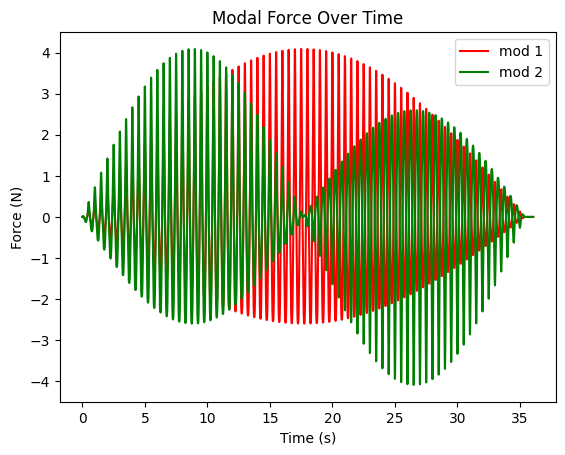

In [16]:
import matplotlib.pyplot as plt
plt.plot(t, F[0, :], label="mod 1", color='r')  # First row
plt.plot(t, F[1, :], label="mod 2", color='g')  # Second row
#plt.plot(t, F[2, :], label="mod 3", color='b')
#plt.plot(t, F[3, :], label="mod 4", color='orange')  # Third row

plt.xlabel('Time (s)')
plt.ylabel('Force (N)')
plt.legend()
plt.title('Modal Force Over Time')
plt.show()


200
400


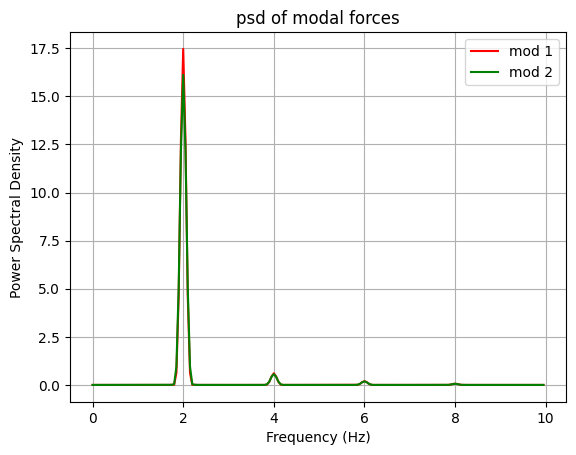

In [17]:
fs = 1/hht 
frequencies, psd_temp = welch(F[0, :], fs=fs, nperseg=1000, nfft=2000,)  # Run welch once to determine size
psd_values = np.zeros((N_bridge, len(psd_temp))) 
#psd_values = np.zeros((N_bridge,np.size(t)))

# Loop through each row of matrix F (each mode) and compute its PSD
for i in range(N_bridge):  # Loop over each row (mode)
    frequencies, psd_values[[i],:] = welch(F[i, :], fs=fs, nperseg=1000, noverlap=500 ,nfft=2000)  # Adjust nperseg as needed
    

frequencies=frequencies[frequencies<(10)] #adjust range of frequency range suitable for analysis
psd=psd_values[:,:np.size(frequencies)]   
print(np.size(frequencies))
print(np.size(psd))

# Plot the PSD for each mode
plt.figure()  
plt.plot(frequencies, psd[0,:], label="mod 1", color='r')
plt.plot(frequencies, psd[1,:], label="mod 2", color='g')
#plt.plot(frequencies, psd[2,:], label="mod 3", color='b')
#plt.plot(frequencies, psd[3,:], label="mod 4", color='orange')
plt.title("psd of modal forces")
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.legend()
plt.grid()
plt.show()


In [18]:

M,K,C,_=MatrixAssemblesymetric(Human,Bridge,mped,kped,cped,xrb,length,linearMass,N_bridge,numped,t[2000])
_,accelerance = calc_frf(M,C,K,frequencies)

ValueError: too many values to unpack (expected 2)

In [5]:
#from solver import MatrixAssemblesymetric,calculate_frf_and_accelerance,g_pj
deltaF= frequencies[4]-frequencies[3]
print(deltaF)
accnmax = np.zeros((np.size(t)))
sigma2=0

for i in range(np.size(t)-1):
    M,K,C,_=MatrixAssemblesymetric(Human,Bridge,mped,kped,cped,xrb,length,linearMass,N_bridge,numped,t[i])
    responce_std =calculate_response_std(M,C,K,frequencies,psd[1,:])
    peakfactor=g_pj(beamFreq,10,length,pedvelocity)
    accnmax[[i]] = peakfactor*responce_std 
    xrb+=t[i+1]*pedvelocity


plt.plot(t, accnmax, label="Mode 1", color='r')  # Plot the first row
#plt.plot(t, accnmax[1, :], label="Mode 2", color='g')  # Plot the second row
plt.title("Peak Modal Acceleration")
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.legend()
plt.grid()
plt.show()

0.04999999999999999


ValueError: shape mismatch: value array of shape (200,1) could not be broadcast to indexing result of shape (1,)

In [4]:
M,K,C,_=MatrixAssemblesymetric(Human,Bridge,mped,kped,cped,xrb,length,linearMass,N_bridge,numped,15)
responce_std =calculate_response_std(M,C,K,frequencies,psd[0,:])
peakfactor=g_pj(beamFreq,1,length,pedvelocity)
print(peakfactor)
print(responce_std)
#sigma=np.trapz(responce_std[:,[0],[0]], x=None, dx=deltaF, axis=0)
#print(sigma)
#plt.loglog(frequencies, , label="Mode 1", color='r')  # Plot the first row
#plt.show()

2.771362478140458
[[0.00000000e+00 1.09769293e-03 4.39902463e-03 9.92890946e-03
  1.77293955e-02 2.78604704e-02 4.04012298e-02 5.54514515e-02
  7.31336350e-02 9.35955864e-02 1.17013654e-01 1.43596753e-01
  1.73591358e-01 2.07287707e-01 2.45027514e-01 2.87213619e-01
  3.34322124e-01 3.86917750e-01 4.45673454e-01 5.11395697e-01
  5.85057349e-01 6.67841022e-01 7.61196898e-01 8.66920999e-01
  9.87262831e-01 1.12507611e+00 1.28403411e+00 1.46894432e+00
  1.68622042e+00 1.94461150e+00 2.25636840e+00 2.63918673e+00
  3.11960502e+00 3.73931003e+00 4.56773151e+00 5.72969786e+00
  7.47436118e+00 1.03808108e+01 1.61703761e+01 3.31531653e+01
  1.75521105e+02 3.57016245e+01 1.87809372e+01 1.30026911e+01
  1.00995131e+01 8.35557378e+00 7.19315413e+00 6.36357153e+00
  5.74219194e+00 5.25967621e+00 4.87438285e+00 4.55979639e+00
  4.29823238e+00 4.07744418e+00 3.88868248e+00 3.72553037e+00
  3.58317489e+00 3.45793552e+00 3.34694976e+00 3.24795791e+00
  3.15915244e+00 3.07907034e+00 3.00651483e+00 2.940

In [9]:
from solver import plot_frf_magnitude
M,K,C,_=MatrixAssemblesymetric(Human,Bridge,mped,kped,cped,xrb,length,linearMass,N_bridge,numped,0)
plot_frf_magnitude(M,C,K,frequencies)

AttributeError: module 'matplotlib' has no attribute 'plot'

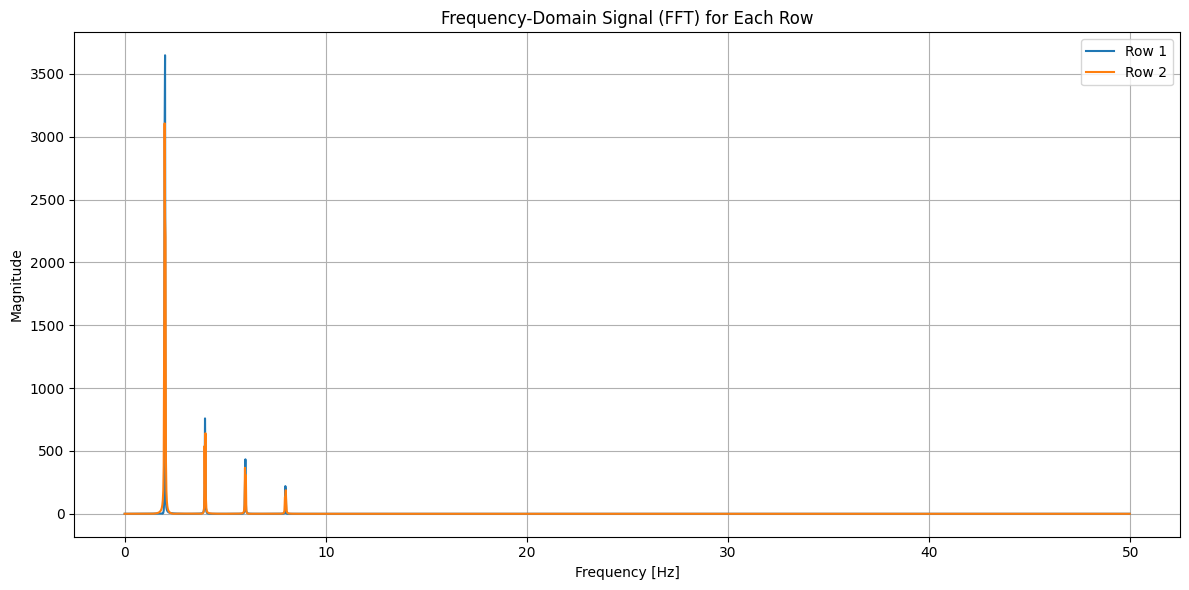

In [8]:
from scipy.signal import detrend, butter, filtfilt
fs=1/hht

# Compute the FFT of the detrended signal for each row
fft_values = np.fft.fft(F, axis=1)

n = F.shape[1]  # Number of sample points per row
frequencies = np.fft.fftfreq(n, 1/fs)  # Frequency bins

# Only take the positive half of the frequencies and FFT
positive_frequencies = frequencies[:n//2]
positive_fft_values = np.abs(fft_values[:, :n//2])

# Plot the FFT for each row
plt.figure(figsize=(12, 6))
for i in range(N_bridge):
    plt.plot(positive_frequencies, positive_fft_values[i, :], label=f'Row {i+1}')

plt.title("Frequency-Domain Signal (FFT) for Each Row")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
